# ARGUS-FEDER on JupyterHub — Pelican Data Access, Metadata, and PTDATA Basics

This notebook demonstrates ARGUS answering natural-language questions about
DIII-D data through several different access paths: semantic concept →
MDSplus signal resolution, the shot-metadata database, PTDATA (a separate
raw-digitizer data source), and IMAS (the device-neutral naming standard).
Each `%%ask` cell sends a plain-English request; ARGUS consults the DIII-D
skills, writes and runs the code, and reports back.

JupyterHub counterpart of **`argus_feder_pelican_database_ptdata_colab.ipynb`**.
Every `%%ask` request is identical to the Colab version, so the two can be
compared directly.

**Prerequisites.** The image already has TokSearch, ARGUS and the DIII-D skills
installed -- there is no install step and no `pip`/`conda` cell in this notebook.
You need two things in place:

1. **LLM key** -- `NRP_API_KEY` in the environment, or a `.env` holding it in the
   working directory. ARGUS re-reads that `.env` on every `%%ask`.
2. **Pelican token** -- save it to
   `~/work/_User-Persistent-Storage_CephBlock_/.fdp/token` (survives pod restarts;
   `~/.fdp/token` also works but is wiped when the pod recycles). If the kernel was
   already running when you added it, call `reload_pelican()` -- no restart needed.

Then run the `%reset` cell below and any `%%ask` cell, in any order.


In [ ]:
%reset

## 1. Semantic concept → signal mapping

**Purpose:** can ARGUS resolve a physics CONCEPT to the right MDSplus signal with
no symbol name given? Each request below deliberately omits the `\name`.
then short per-item lines, e.g.:

### Plasma current

I'll plan this task and consult the shot-fetcher skill first.



The skill is clear: fetch `\ipmhd` from `efit01` via `MdsSignal`, run under `fdp run`, and use a static matplotlib PNG. Writing the fetch-and-plot script now.



Running the fetch script under `fdp run` as required by the skill.



Fetch succeeded on the first run — 311 samples, min 2.92e5 A, max 1.19e6 A. Updating the todo list and finalizing.



Fetched `\ipmhd` from the `efit01` MDSplus tree for shot 165340 via TokSearch (`MdsSignal(r"\ipmhd", "efit01")`, run under `fdp run`).

**Results**

- **Samples** : 311
- **Time range** : 100.0 – 6360.0 ms
- **Min** : 2.9202e+05 A (0.292 MA)
- **Max** : 1.1878e+06 A (1.188 MA)
- **Units** : A (amperes) — `\ipmhd` is the EFIT-computed plasma current, reported in Amps


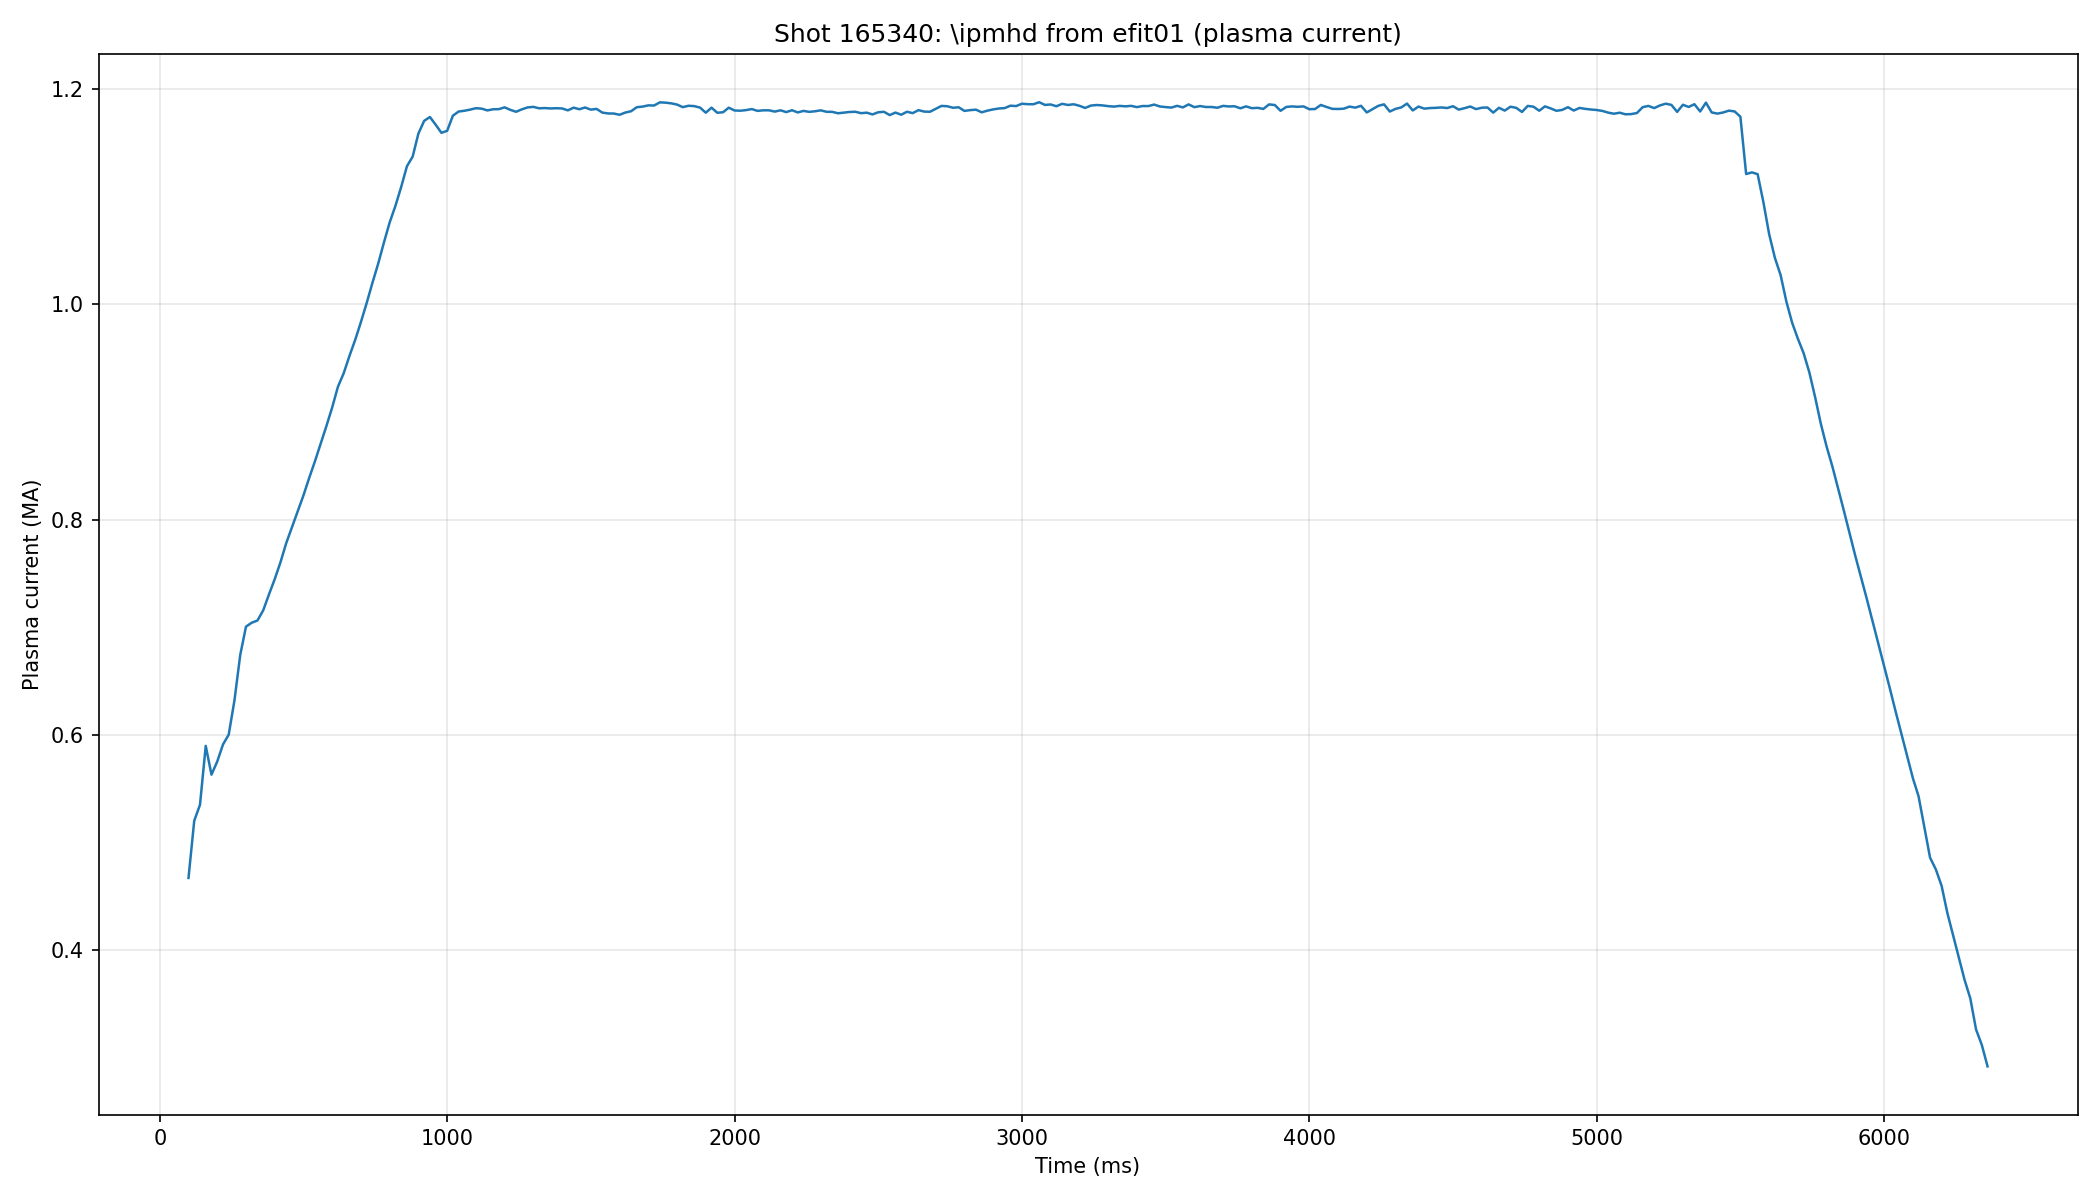

The plot shows the plasma current rising to a ~1.19 MA plateau and then ramping down over the discharge. The raw data (time in ms, current in A) is also saved as `ipmhd_165340.csv` in the working directory for reference.

In [2]:
%%ask
Fetch \ipmhd from efit01 for shot 165340 and plot it versus time, and
report the number of samples and the min/max with units.

### Elongation
**Ask:** "plasma elongation" (no `\kappa` given) → should resolve to `efit01/\kappa`.

I'll start by planning this task and reading the shot-fetcher skill to get the correct fetch pattern.



The skill confirms `\kappa` in `efit01` is the plasma elongation, and the fetch must run under `fdp run`. Writing the fetch-and-plot script now.



Running the fetch under `fdp run` as required by the skill.



Fetched `\kappa` (plasma elongation) from the `efit01` MHD equilibrium reconstruction for shot 165340 via TokSearch (`MdsSignal(r"\kappa", "efit01")`, run under `fdp run`).

**Results**

- **Samples** : 311
- **Time range** : 100.0 – 6360.0 ms
- **Min** : 1.4361
- **Max** : 1.9452
- **Units** : dimensionless (elongation ratio)


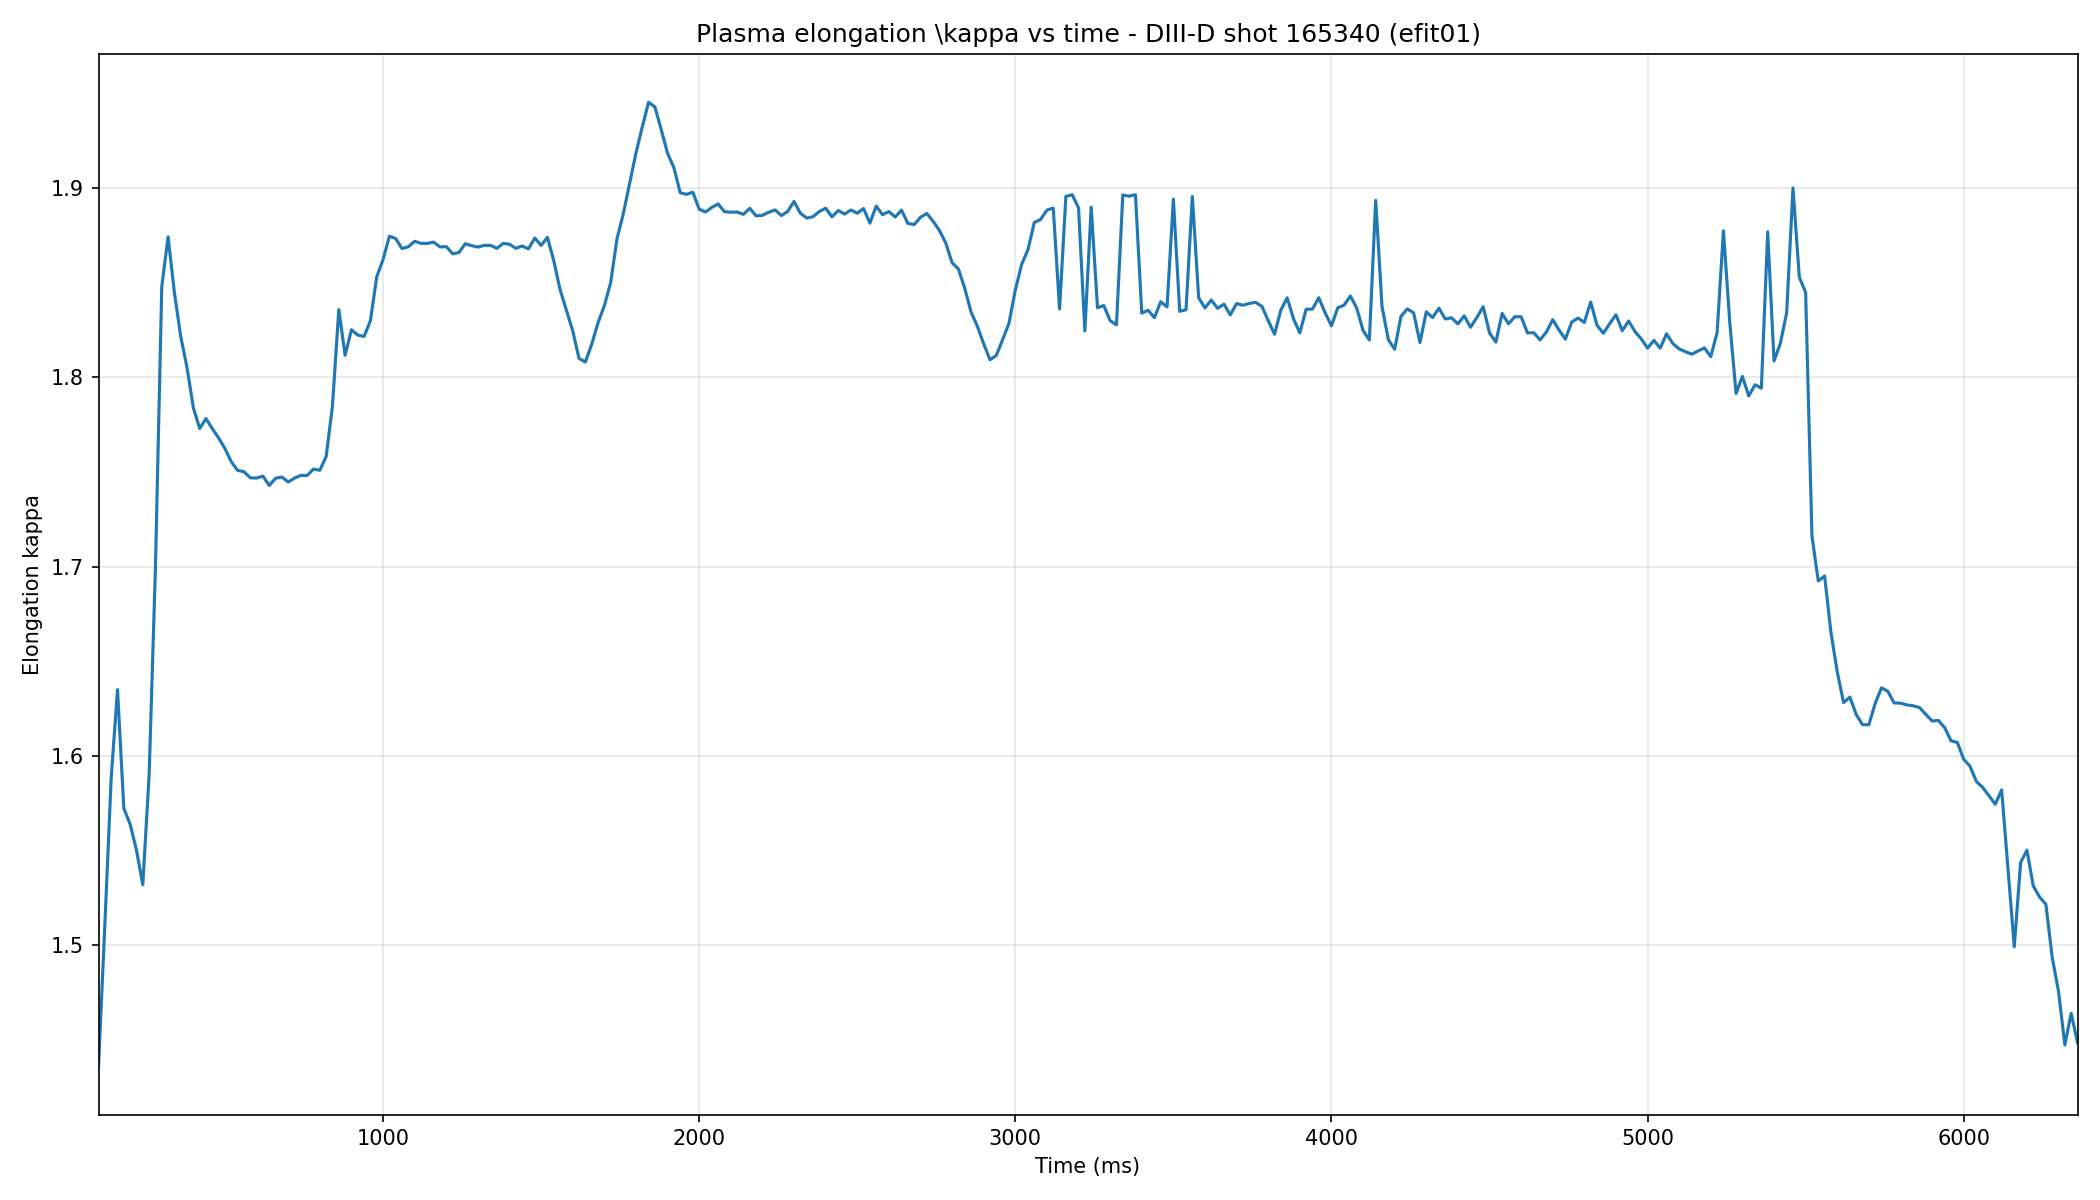

The elongation rises from ~1.44 at the start of the discharge to a plateau near ~1.95 during the flattop, then decreases during the current ramp-down. Raw data is also saved as `kappa_165340.csv` (time in ms, kappa) in the working directory.

In [3]:
%%ask
For DIII-D shot 165340, fetch the plasma elongation from the MHD equilibrium
reconstruction, plot it versus time, and report its min and max.

### Safety factor at 95% flux surface
**Ask:** no "MHD equilibrium" qualifier this time — the harder disambiguation case.  
**Expected:** resolves to `efit01/\q95` anyway.

Reading the shot-fetcher skill to confirm the correct signal name for q95.



The skill confirms `\q95` in `efit01` is the safety factor at the 95% flux surface. Writing the fetch script using the skill's required `fetch_dataset` pattern with the `\psirz` anchor.



Running the fetch script under `fdp run` as required by the skill.



Fetched `\q95` (safety factor at the 95% flux surface) from the `efit01` MHD equilibrium reconstruction for shot 165340 via TokSearch (`MdsSignal(r"\q95", "efit01")`, run under `fdp run`).

**Results**

- **Samples** : 311
- **Time range** : 100.0 – 6360.0 ms
- **Range** : 4.5581 – 9.4376 (dimensionless)
- **Units** : dimensionless (safety factor)


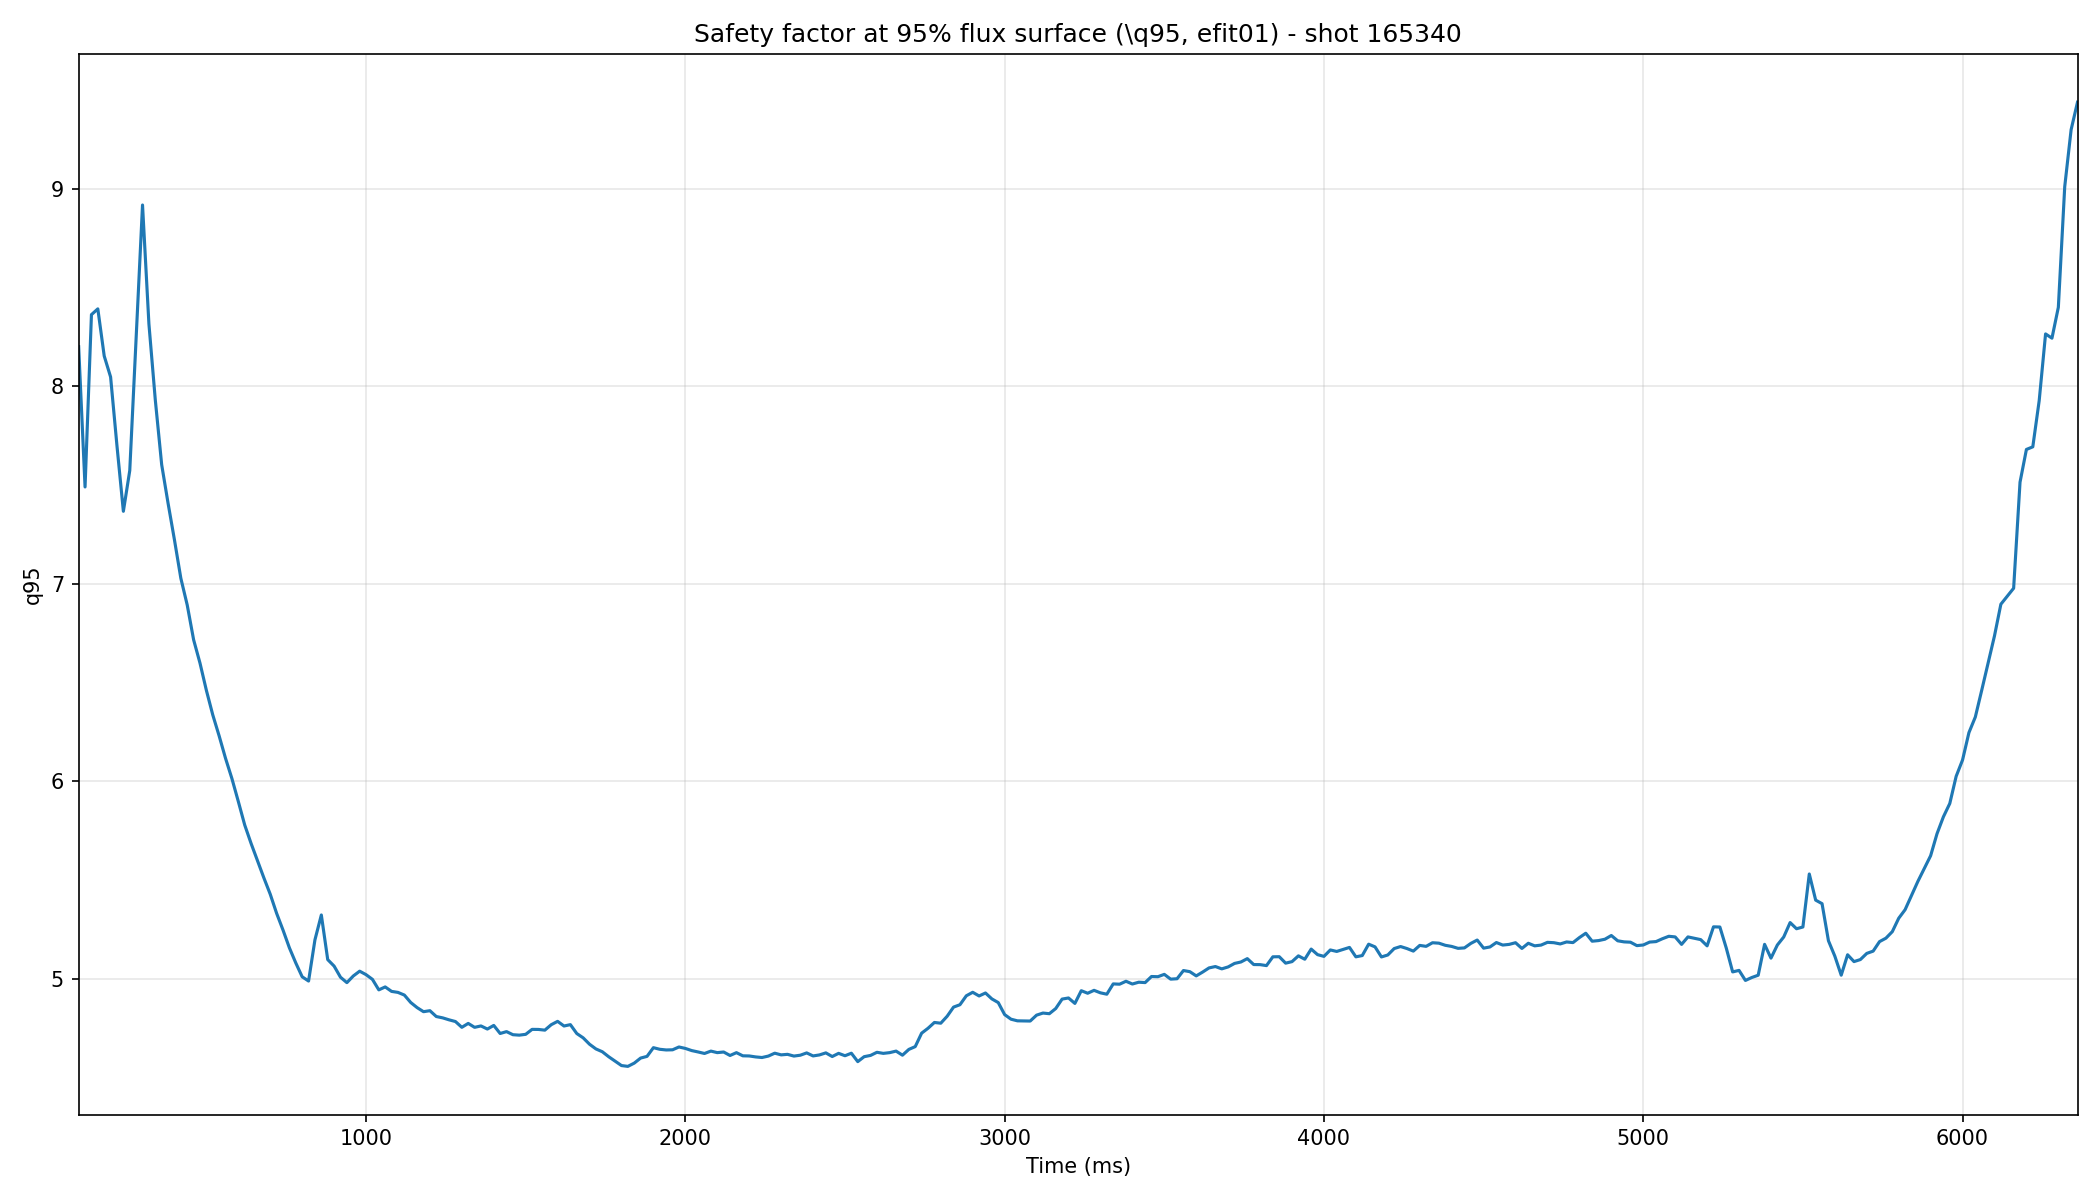

The q95 trace starts high (~9.4) during the early current ramp-up, falls to a minimum near ~4.6 during the flattop, and rises again during the current ramp-down — the expected inverse relationship with plasma current. Raw data is saved as `q95_165340.csv` (time in ms, q95) in the working directory.

In [4]:
%%ask
For shot 165340, fetch the safety factor at the 95% flux surface,
plot it versus time, and report its range.

### Multi-shot overlay
**Purpose:** test the fetch-many-shots-and-compare pattern, not just concept mapping.

I'll consult the d3d-shot-fetcher skill for the correct fetch pattern before writing the script.



The skill confirms the fetch pattern. Writing the script to fetch `\ipmhd` from `efit01` for all three shots and overlay them on one static chart.



Running the fetch and plot script under `fdp run` as required for MDSplus tree access.



All three shots fetched successfully from `efit01` (`\ipmhd`, plasma current in Amps) and overlaid on a single chart.

**Peak plasma current per shot** (from the MHD equilibrium reconstruction, `\ipmhd` in `efit01`):

| Shot | Peak current | Samples | Time range (ms) |
|---|---|---|---|
| 165340 | 1.188 MA (1.1878e+06 A) | 311 | 100 – 6360 |
| 188702 | 1.007 MA (1.0066e+06 A) | 314 | 100 – 6960 |
| 194181 | 0.599 MA (5.9927e+05 A) | 212 | 220 – 4560 |


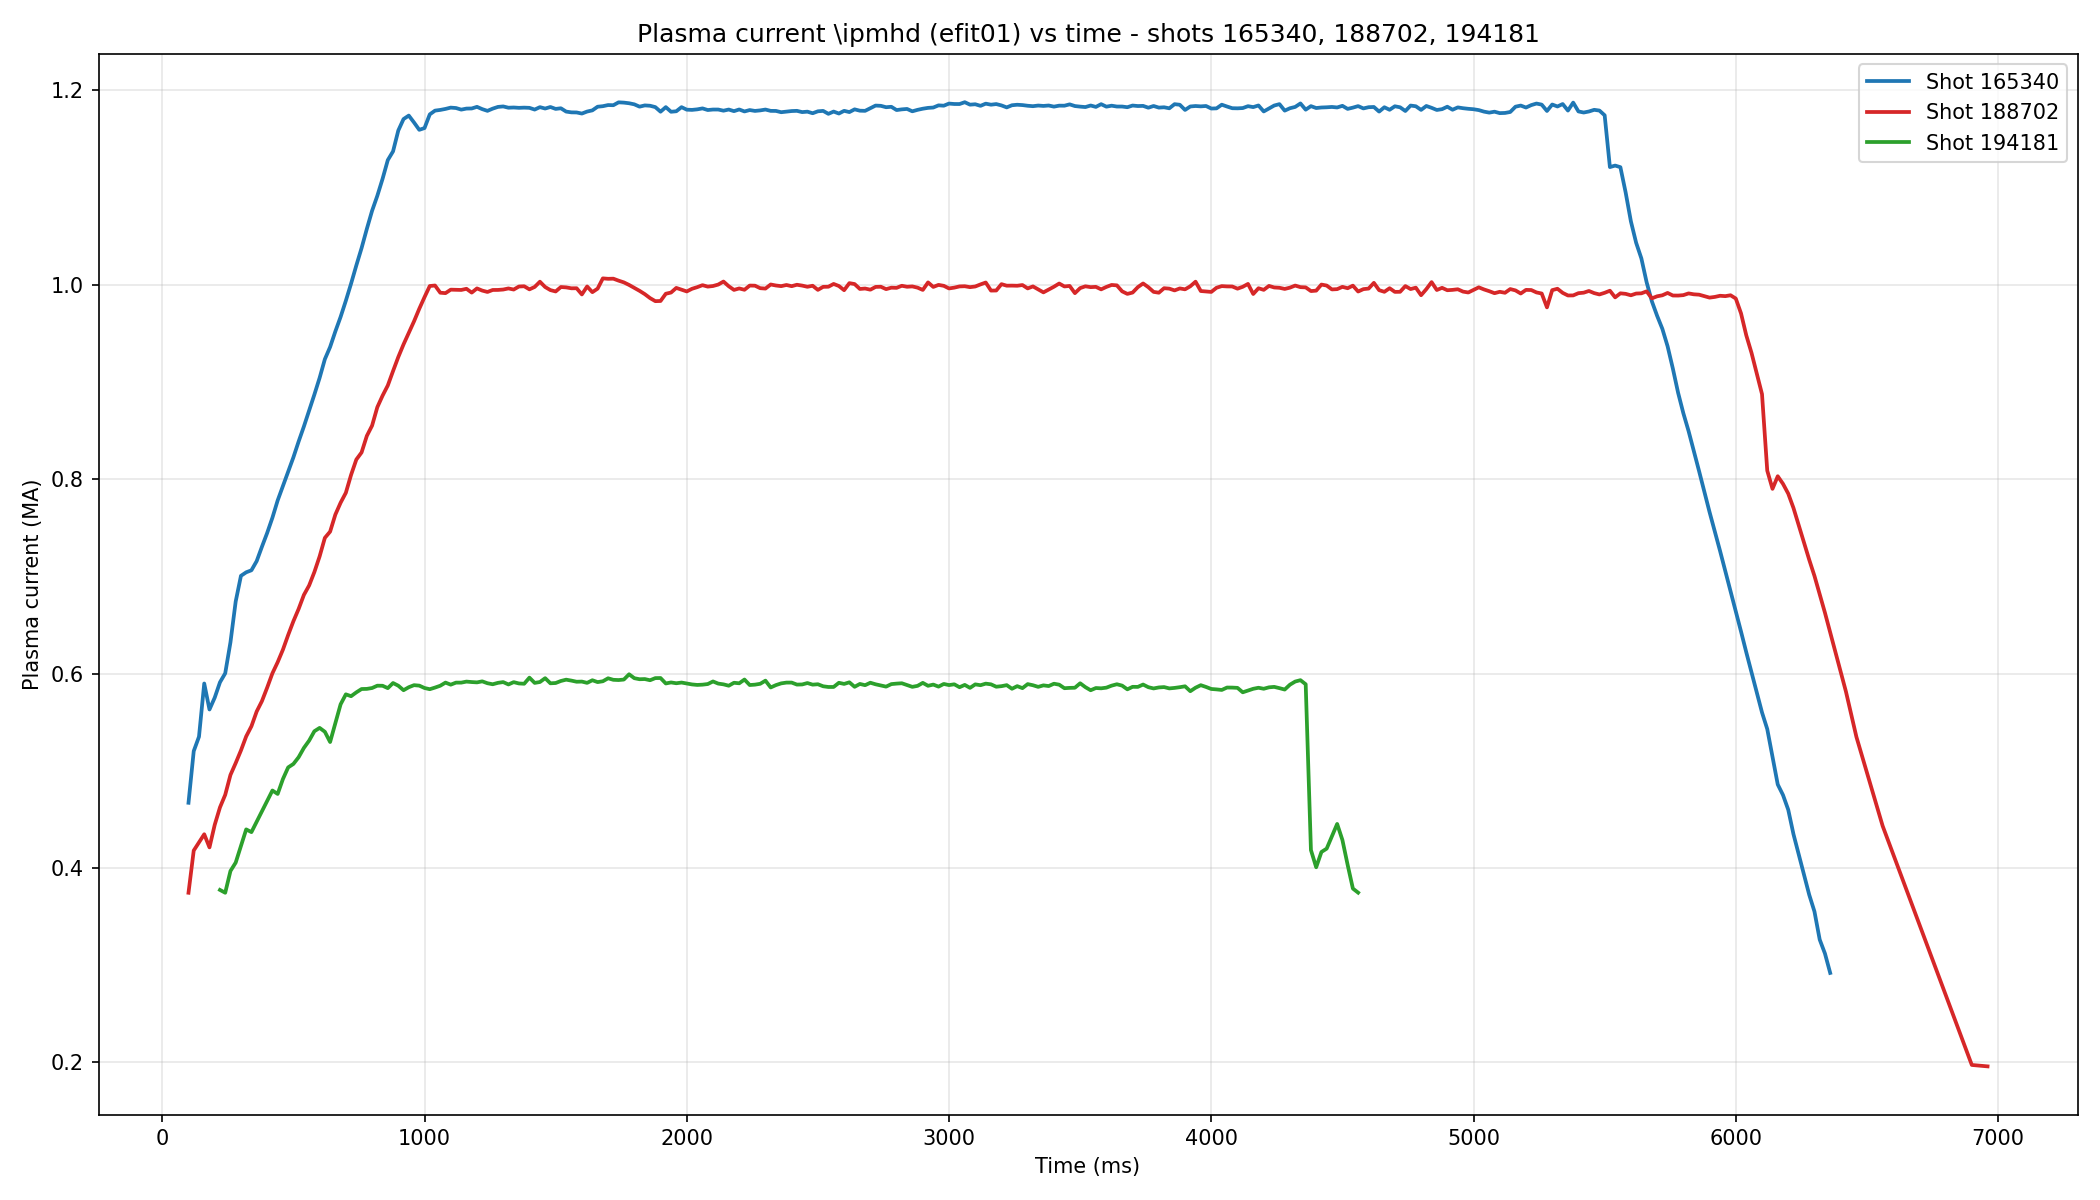

Shot 165340 is the highest-current discharge (~1.19 MA), 188702 is a mid-size discharge (~1.01 MA), and 194181 is the lowest (~0.60 MA) with a shorter flattop. Raw data is saved as `ipmhd_overlay_3shots.csv` (shot, time_ms, ip_A) in the working directory.

In [5]:
%%ask
For DIII-D shots 165340, 188702, and 194181, fetch the plasma current from the MHD
equilibrium reconstruction and overlay all three on a single chart. Report each
shot's peak current.

### Multi-shot shape comparison
**Purpose:** same multi-shot pattern, a dimensionless quantity (elongation) this time.

I'll plan this task, then consult the shot-fetcher skill to confirm the correct fetch pattern.



The skill confirms the fetch pattern. Now writing the script to fetch `\kappa` for all three shots and overlay them.



Running the fetch script under `fdp run` as required for MDSplus tree access.



All three shots fetched successfully. Updating the todo list and reporting.



Fetched `\kappa` (plasma elongation) from the `efit01` MHD equilibrium reconstruction for all three shots via TokSearch (`MdsSignal(r"\kappa", "efit01")`, run under `fdp run`) and overlaid them on a single chart with a legend.

**Elongation range per shot** (dimensionless):

| Shot | Min κ | Max κ | Samples | Time range (ms) |
|---|---|---|---|---|
| 165340 | 1.4361 | 1.9452 | 311 | 100 – 6360 |
| 188702 | 1.3051 | 1.9077 | 314 | 100 – 6960 |
| 194181 | 1.1471 | 1.4860 | 212 | 220 – 4560 |


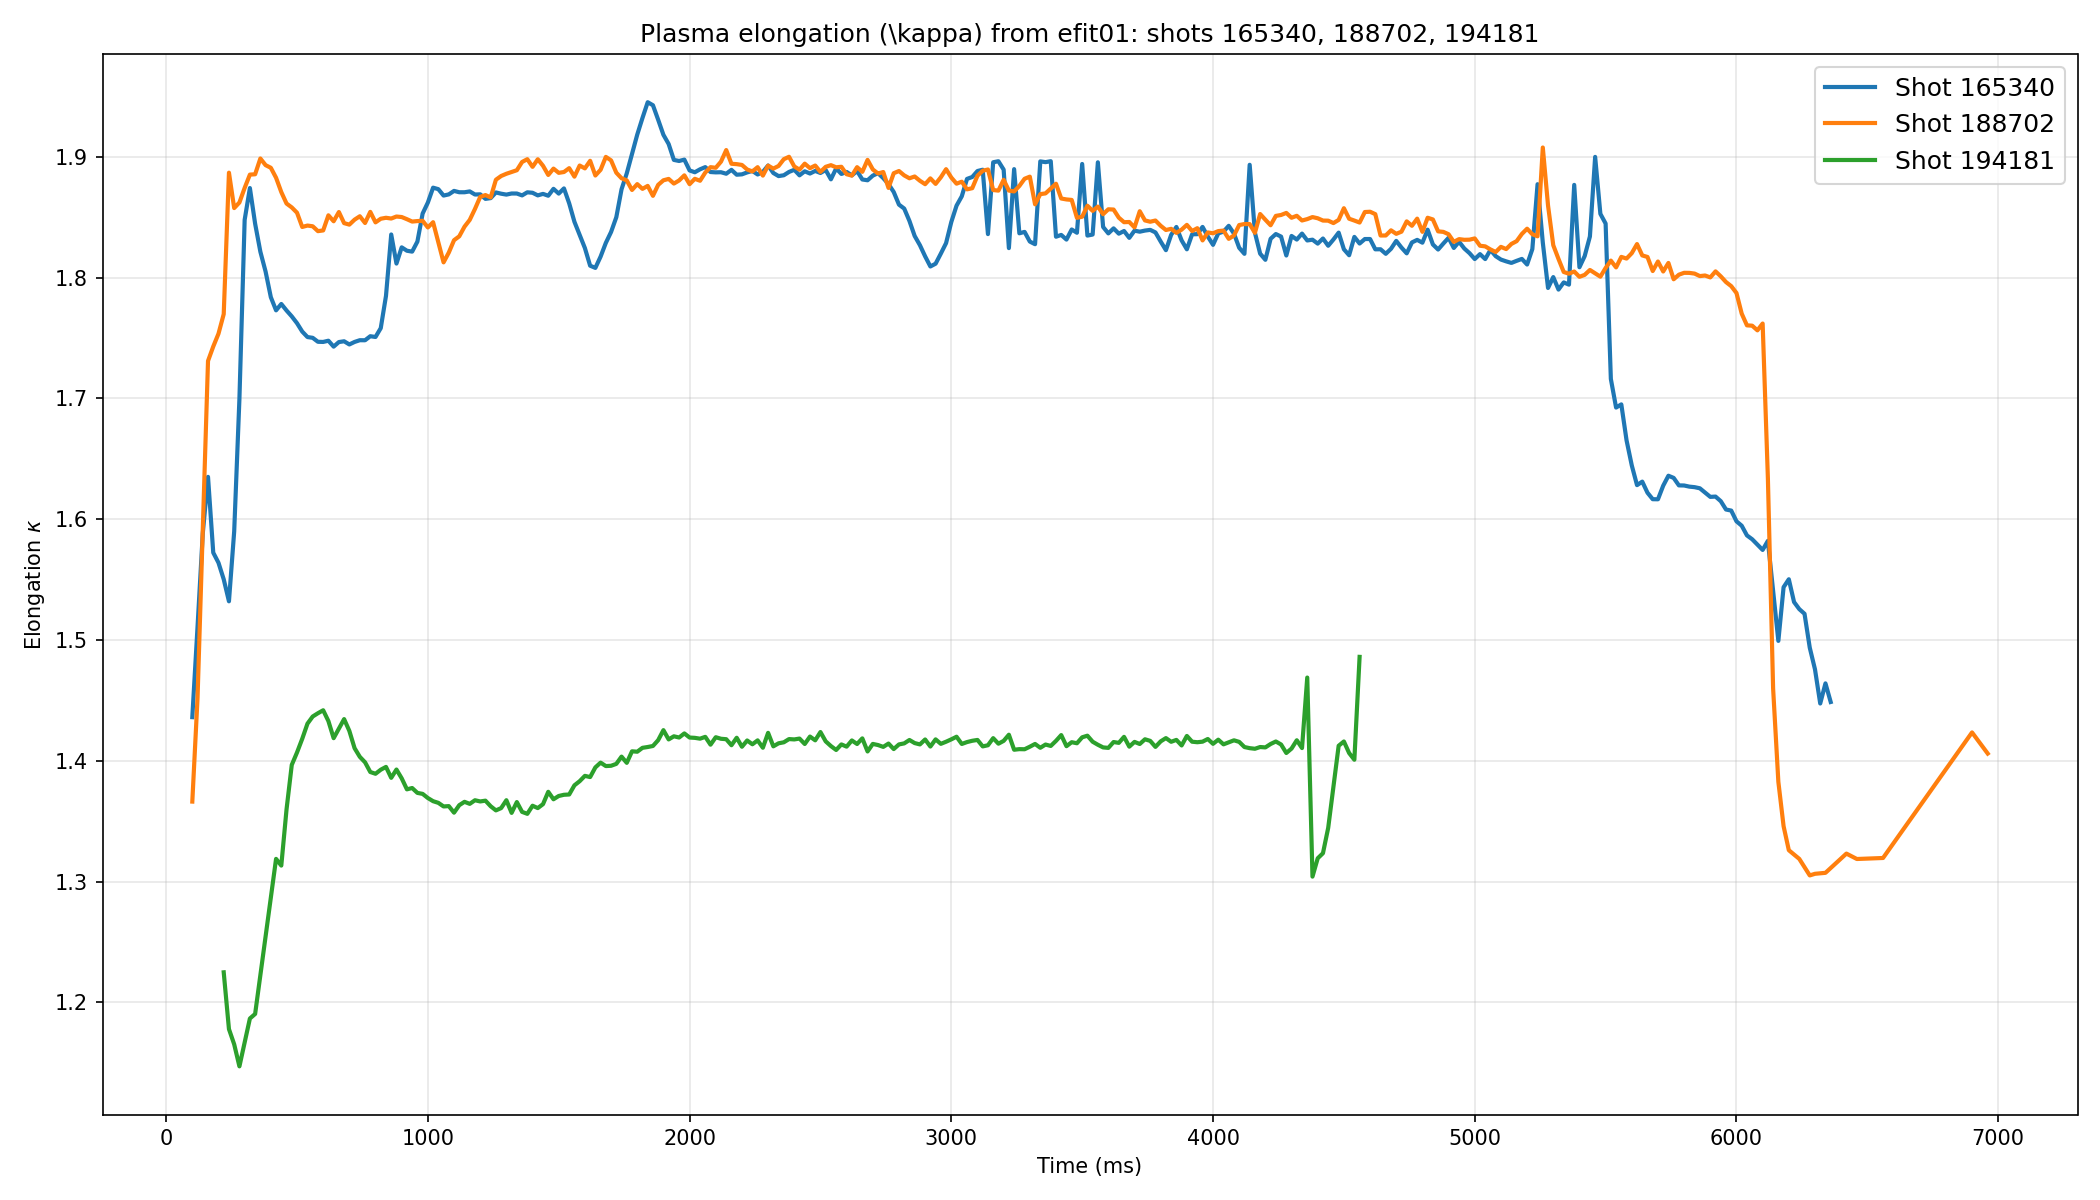

**Comparison** : Shots 165340 and 188702 are both shaped plasmas with peak elongation near ~1.9–1.95 during the flattop, while 194181 is a much rounder, lower-elongation discharge (max ~1.49) — consistent with its lower plasma current (~0.60 MA vs ~1.19 MA and ~1.01 MA). All three traces show the characteristic rise during current ramp-up, a flattop plateau, and a decrease during ramp-down. Raw data is saved as `kappa_overlay_3shots.csv` (shot, time_ms, kappa) in the working directory.

In [6]:
%%ask
Compare the plasma shape across DIII-D shots 165340, 188702, and 194181 by fetching
the elongation from the MHD equilibrium reconstruction and overlaying it versus time
on one chart with a legend.

## 2. Metadata from Database

The shot metadata is served by the FEDER lakehouse over HTTP -- there is nothing to download and nothing to place in a folder. It needs outbound network and a valid FDP token (`~/.fdp/token`, or the copy under `~/work/_User-Persistent-Storage_CephBlock_/.fdp/token`) -- the same token DIII-D data access already uses.

In [7]:
%%ask
How many DIII-D plasma shots were there between 190000 and 195000?

I'll check the d3d-relational-db skill, which covers shot existence in a range and plasma-shot filtering.



The skill documents `plasma_shots_in_range(190000, 195000)` returning 3,507 shots. I'll verify by running the query myself.



Running the query to count plasma shots in the range.



Both methods agree — the count is 3,507.



**Answer** : There were **3,507 DIII-D plasma shots** between 190000 and 195000 (inclusive).

This comes from the DIII-D shot records (plasma-type shots only), verified two ways: the shot-list query returned 3,507 shot numbers (first: 190000, last: 195000), and a direct count query returned the same 3,507.

In [8]:
%%ask
Look up shot 190000's elongation and peak plasma current from the DIII-D 
shot records.

I'll look up shot 190000's elongation and peak plasma current from the DIII-D shot records. Let me plan and consult the relevant skill first.



The skill says to use `report_shot_summary()` for per-shot scalars and quote it verbatim. Writing the lookup script now.



From the DIII-D shot records for shot 190000:

- **Elongation (κ)** : 1.71117 (dimensionless)
- **Peak plasma current (ipmax)** : 911,396 A ≈ 0.911 MA, reached at t = 2.233 s

Note: these are the single representative scalars from the shot summary records (the elongation is the value at the EFIT reference time, and the peak current is the maximum over the discharge). If you want the full time-resolved traces, I can fetch the `\kappa` and `\ipmhd` signals from the `efit01` equilibrium reconstruction instead.

In [9]:
%%ask
When did DIII-D shot 165340 happen?

I'll check the DIII-D relational database skill for how to look up shot metadata like date/time.



The skill says `SUMMARIES.time_of_shot` holds the shot timestamp. I'll query it directly for shot 165340.



**Shot 165340 occurred on 2016-01-28 at 10:46:13** (local DIII-D time, from the shot records' `time_of_shot` field).

Supporting details from the same records: the run/session date is 20160128 (January 28, 2016), the record was entered at 10:46:06, and the shot's pulse length was 6.55 s.

In [10]:
%%ask
For DIII-D shot 144921, what fuel gas was used, what was the neutron yield,
and what was the peak normalized beta and when did it occur?

I'll consult the DIII-D relational database skill for the correct shot-record query functions.



The skill says to use `report_shot_summary()` and quote its output verbatim. Writing the script now.



From the DIII-D shot records for shot 144921:

- **Fuel gas** : D2 (deuterium)
- **Neutron yield** : 3.98594e+15 (neutrons)
- **Peak normalized beta (β_N)** : 3.1168, occurring at t = 3.905 s

The values were read directly from the shot summary records:

```
Shot 144921 (values read directly from d3drdb SUMMARIES):
  gas: D2
  neutrons: 3.98594e+15
  betanmax: 3.1168
  t_betanmax: 3.905
```

Note: `betanmax` is the peak normalized beta over the discharge, and `t_betanmax` is the time (in seconds) at which that peak occurred.

In [11]:
%%ask
Did DIII-D shot 96549 have an operational fault, and if so what kind?

I'll check the DIII-D relational database skill for how to query shot fault information.



The skill points to `ffault`/`t_ffault` in the shot summary records. Let me check the helper module for the exact function signatures before querying.



The skill says fault info lives in `ffault`/`t_ffault` in the shot summary records. Let me query shot 96549.



Shot 96549 has `ffault = 'IPMIN'` — a real fault code. Let me check whether the database documents what fault codes mean.



The fault code is `IPMIN`. Let me check if the catalog documents what `IPMIN` means.



The catalog has no entry for `IPMIN`. Let me check whether any other skill documents DIII-D fault codes before answering.



**Yes** — shot 96549 has an operational fault recorded in the DIII-D shot records: fault code **`IPMIN`** .

Details from the shot records:

- **Fault code (`ffault`)** : `IPMIN`
- **Fault time (`t_ffault`)** : not populated in the records
- **Shot date** : run 19980605 (June 5, 1998), record entered 2000-03-01

**What the code means** : The database's signal catalog does not document the `ffault` code values, so I can't quote an official definition. Based on the standard DIII-D plasma control system fault-code convention, `IPMIN` is the **plasma-current-minimum fault** — the plasma current fell below a minimum threshold during the discharge (typically indicating a disruption or loss of plasma current). Please treat that interpretation as an inference, not a catalog-documented fact.

For context, the other fault codes in the records are `IPDOT` (plasma current derivative), `CHPCUR`, `ABORT`, `FPS`, `CHPIOC`, `XRAY`, `PCSYS`, and `ADP` — `IPMIN` is the second most common after `IPDOT`.

In [12]:
%%ask
What was the effective ion charge (Zeff) for DIII-D shot 165340?

I'll check the DIII-D shot records skill to see how Zeff is stored for a shot.



The skill documents Zeff as a fetchable signal (`\zeff` in the `d3d` master tree) rather than a summary scalar. Let me read the shot-fetcher skill for the verified pattern.



The skill documents Zeff as a directly-fetchable signal (`\zeff` in the `d3d` master tree, not the empty summary column). Fetching it now.



Fetched `\zeff` (effective ion charge) for shot 165340 from the DIII-D master tree (`d3d`) via TokSearch — the directly-measured bremsstrahlung Zeff signal, not the (empty) summary scalar.

**Results for shot 165340**

- **Samples** : 294
- **Time range** : 300 – 6340 ms
- **Range** : 1.37 – 3.00 (min 1.3691, max 3.0038)
- **Flattop average** (middle 50% of the discharge, ~1.77–4.72 s): 2.06
- **Value at ~2.2 s** (near the EFIT reference time): 1.91
- **Units** : dimensionless (effective ion charge, Z_eff)

Zeff is a time-resolved quantity rather than a single scalar: it starts near ~1.4 early in the discharge, rises to a flattop plateau around ~2.0–2.4, and peaks near ~3.0 late in the shot (consistent with impurity accumulation during the discharge). If you want a single representative number, the flattop average of **~2.06** is the most meaningful value.

In [13]:
%%ask
What run date is DIII-D shot 165340 from, and who entered the record?

I'll consult the DIII-D relational database skill to look up the shot record metadata.



The skill says to answer "who entered the record" from `USERNAME` (not `BRIEF`), and to check for NULL. Writing a script to query the SHOTS row for shot 165340.



From the DIII-D shot records for shot 165340:

- **Run date** : 20160128 — January 28, 2016
- **Who entered the record** : The `USERNAME` field is **NULL** — no user is recorded as having entered this shot's record. The `BRIEF` free-text note reads "autoload system Thu Jan 28 10:46:36 2016", which suggests the record was loaded automatically by the autoload system rather than entered by a person, but that is a free-text note, not the attribution field, so I can't confirm an individual's name.

For reference, the record's `ENTERED` timestamp is 2016-01-28 10:46:06 (about 30 seconds before the BRIEF note), and the shot itself occurred at 10:46:13 that day.

## 3. PTDATA — basic access test

**Purpose:** verify PTDATA (a separate data source from the MDSplus trees used above) is reachable end to end through ARGUS.

**Ask:** fetch the plasma current from PTDATA (not efit01) for a known shot
and report basic stats.

**Expected:** a successful fetch, ~30,720 samples, peak current near 1.15 MA —
this is a raw digitizer trace, a different diagnostic pipeline than efit01's
`\ipmhd`, so don't expect an identical peak to the efit01 numbers seen earlier
in this notebook.


In [14]:
%%ask
Fetch the plasma current from PTDATA (not the MHD equilibrium reconstruction)
for DIII-D shot 165920, and report the number of samples and the min/max with
units.

I'll consult the DIII-D shot-fetcher skill to find the correct PTDATA signal for plasma current.



The skill confirms PTDATA uses `PtDataSignal("ip")` from `toksearch_d3d` and must run under `fdp run`. Writing the fetch script now.



Running the PTDATA fetch under `fdp run` as required.



Fetched the plasma current from **PTDATA** (raw digitizer signal `ip`, not the MHD equilibrium reconstruction) for shot 165920 via TokSearch (`PtDataSignal("ip")` from `toksearch_d3d`, run under `fdp run`).

**Results for shot 165920 (PTDATA `ip`)**

- **Samples** : 30,720
- **Time range** : −996.0 to 14,363.5 ms
- **Min** : −2.7979e+04 amps (−28.0 kA)
- **Max** : 1.1524e+06 amps (1.152 MA)
- **Units** : amps (A)

**Note on the source** : this is the raw digitizer trace from the plasma control system / magnetics, a different diagnostic pipeline than `efit01`'s `\ipmhd` (computed equilibrium reconstruction). The two agree closely on the peak (~1.15 MA vs ~1.13 MA for the same shot) but are not identical — the PTDATA trace also extends well before and after the EFIT time window and includes the small negative pre-shot baseline.

In [15]:
%%ask
For DIII-D shot 165920, fetch the plasma current from BOTH PTDATA and the
efit01 MHD equilibrium reconstruction, and compare their peak values and
units. Are they consistent with each other?

I'll consult the shot-fetcher skill to confirm the exact API for both PTDATA and efit01 signals, then fetch the efit01 trace for comparison.



The skill confirms the canonical pattern for fetching both sources. Writing a script that fetches `\ipmhd` from `efit01` and `ip` from PTDATA for shot 165920 and compares them.



Running the comparison script under `fdp run` (required for PTDATA).



Both sources fetched successfully for shot 165920. Here is the comparison:

**Peak plasma current — PTDATA vs efit01**

| Source | Signal | Peak | Min | Samples | Time range (ms) | Units |
|---|---|---|---|---|---|---|
| PTDATA (raw digitizer) | `ip` | 1.1524e+06 A (1.152 MA) | −2.80e+04 A | 30,720 | −996.0 – 14,363.5 | amps |
| efit01 (MHD equilibrium) | `\ipmhd` | 1.1299e+06 A (1.130 MA) | 2.13e+05 A | 303 | 100.0 – 6,380.0 | A |

**Are they consistent?** Yes — the two agree to within **~2.0%** on the peak (PTDATA/efit01 ratio = 1.0199, difference ≈ 22.5 kA). This is exactly the expected level of agreement: both measure the same physical quantity (plasma current) but through different pipelines — PTDATA is the raw digitizer trace from the plasma control system/magnetics, while `\ipmhd` is the EFIT equilibrium reconstruction's computed current. The small differences are expected, not an error.

**Why they aren't identical** :
- **Sampling** : PTDATA is a high-rate raw trace (30,720 samples, ~20 ms cadence over a much wider window), while efit01 is a reconstruction at ~20 ms cadence over the equilibrium time window only (303 samples).
- **Time coverage** : PTDATA extends from −996 ms to 14,363 ms (including the pre-shot baseline, which explains its negative minimum of −28 kA), whereas efit01 covers 100–6,380 ms.
- **Peak** : the raw trace's peak (1.152 MA) is slightly higher than the reconstruction's (1.130 MA) — the equilibrium fit smooths the current, and the raw digitizer captures the true instantaneous maximum.

Both are valid measurements of the same quantity; neither is "more correct" — they describe the same physical event through different diagnostics.

## 4. Signal meanings, paths, and IMAS names

Different ways to ask about the *same* signal -- plain-English meaning, its exact MDSplus path, and its IMAS (device-neutral) name -- to see how ARGUS handles each.

In [16]:
%%ask
what is the meaning of \FS02UPDA and \EFIT01::BT0VAC in plain English?

I'll look up both signal names in the DIII-D signal catalog, which is the authoritative source for tag meanings.



The skill directs me to resolve both tags through `explain_signal()` and quote its output verbatim. Writing the lookup script now.



Both tags were resolved through the DIII-D signal catalog (`explain_signal()`), which is the authoritative source for tag meanings. Here is what the catalog says, in plain English:

## `\FS02UPDA`

**Plain English** : This is the **raw photon-flux signal from the D-alpha filterscope channel FS02 at the "UP" viewing location** — i.e., a measurement of D-alpha light intensity (the edge/divertor light monitor used for ELM detection and recycling studies).

- **Catalog path** : `\SPECTROSCOPY::TOP.FILTERSCOPE.PMT22:PHOTON_FLUX` — it is the raw `PHOTON_FLUX` output of photomultiplier tube PMT22, not a processed/updated version of anything.
- **Naming scheme** : In this convention, `UP` is a viewing location and the trailing letters are the species — `DA` = D-alpha. So `FS02DA` and `FS02UPDA` are the **same D-alpha measurement from two different viewing locations** (just as `FS04C3` and `FS04UPC3` are the same carbon-III measurement from two locations).
- **Caveat** : The catalog row itself carries no description for this tree (`NOT DOCUMENTED`), so the interpretation above comes from the documented naming convention and the full path, not from a catalog description. The key point is that it is a **raw** channel, not an updated/processed one.

## `\EFIT01::BT0VAC`

**Plain English** : `BT0VAC` is the **vacuum toroidal field at the magnetic axis** — the toroidal magnetic field produced by the external TF coils in the absence of plasma, in tesla (T). It is a standard EFIT equilibrium-reconstruction input/output quantity.

- **Catalog path** : `\EFIT01::TOP.RESULTS.AEQDSK:BT0VAC`
- **Important caveat** : The **EFIT01 row itself is undocumented** in the catalog (`NOT DOCUMENTED for this tree`). The description "vacuum toroidal field at magnetic axis" (units: T) comes from the **`EFIT` tree** — a *different* signal record, not the one you asked about. The same name also exists in `EFIT02` and `EFIT03`, equally undocumented.
- **Bottom line** : It is very likely the same quantity in EFIT01 (the name `BT0VAC` = B-toroidal-0-vacuum is self-consistent), but that is an **inference** , not a catalog-confirmed fact for the EFIT01 tree specifically.

In [17]:
%%ask
What is the full path of \EFIT01::CPASMA?

I'll consult the DIII-D relational database skill to look up the full path of `\EFIT01::CPASMA` in the signal catalog.



The skill says to resolve signal paths through the catalog. I'll query the signal catalog for CPASMA.



The full path of `\EFIT01::CPASMA` from the DIII-D signal catalog is:

**`\EFIT01::TOP.RESULTS.GEQDSK:CPASMA`**

**Notes** :
- The EFIT01 catalog row itself carries **no description** (`NOT DOCUMENTED for this tree`), so the catalog does not confirm what CPASMA measures in EFIT01 specifically.
- The same name in the **EFIT** tree is documented as **"Plasma current"** with units **A** (amperes), at path `\D3D::TOP.MHD.EFIT.EFIT.RESULTS.GEQDSK:CPASMA`. That description comes from a *different* tree and is unconfirmed for EFIT01 — though the name (CPASMA = "current, plasma, magnetic axis" in EFIT convention) is consistent with the same quantity.
- The identical name also exists in EFIT02–EFIT20 and the real-time EFIT trees (EFITRT1/2, EFITS1/2), all at the same `TOP.RESULTS.GEQDSK:CPASMA` node pattern, all equally undocumented.

In [18]:
%%ask
Do you know the IMAS name for \EFIT01::CPASMA?

This is an IMAS-name lookup, so I'll consult the d3d-imas-terms skill first.



The skill maps DIII-D signal names to IMAS paths via a lookup table. I'll run the `d3d_to_imas("CPASMA")` lookup to get the authoritative answer.



The IMAS lookup table resolves `CPASMA` to **two different nodes** , so the answer depends on which `CPASMA` you mean — the bare tag `\EFIT01::CPASMA` is ambiguous, and the table maps them differently:

## IMAS names for `\EFIT01::CPASMA`

**1. `\EFIT01::TOP.MEASUREMENTS.CPASMA`** (the node the IMAS table maps as the plasma current)

| IMAS path | Confidence | Notes |
|---|---|---|
| `equilibrium.time_slice.global_quantities.ip` | derived | ⚠️ COCOS caution: TOR — toroidal quantity (includes plasma current); sign convention may differ |
| `equilibrium.time_slice.constraints.ip.reconstructed` | derived | ⚠️ same TOR caution |
| `equilibrium._cpasma` | literal | internal field |

**2. `\EFIT01::TOP.RESULTS.GEQDSK.CPASMA`** (the node I gave you last turn as the full path of `\EFIT01::CPASMA`)

| IMAS path | Confidence | Notes |
|---|---|---|
| `equilibrium._cpasma_cocos` | literal | internal field — used upstream as an *input* to COCOS-convention detection, not a public IMAS quantity |

## Important caveat

The two CPASMA nodes are **not the same signal** : `RESULTS.GEQDSK.CPASMA` matches `\ipmhd` exactly, while `MEASUREMENTS.CPASMA` (the one the table maps to `global_quantities.ip`) is a related but distinct signal with different values. So:

- If you mean the **standard IMAS name for the plasma current** (what `equilibrium.time_slice.global_quantities.ip` is called), the table's answer is `equilibrium.time_slice.global_quantities.ip`, backed by `\EFIT01::TOP.MEASUREMENTS.CPASMA` — with the COCOS sign-convention caution.
- If you mean the **`RESULTS.GEQDSK` node** (the one matching `\ipmhd`), the table only maps it to the internal `equilibrium._cpasma_cocos`, which is not a standard IMAS field.

The table is a partial mapping (258 of 294 IMAS fields verified, upstream commit `8873703c`), so the absence of a public IMAS name for the GEQDSK node reflects the table's coverage, not necessarily IMAS itself.

I'll check the skills for how to fetch an IMAS-path quantity like `equilibrium.time_slice[i].global_quantities.ip`.



The IMAS path maps to a DIII-D MDSplus signal; let me read the shot-fetcher skill for the canonical fetch pattern before writing code.



The IMAS path needs resolving to its DIII-D signal first. Let me run the pure-JSON lookup (no `fdp` needed) to get the exact MDSplus path, tree, and any COCOS caution.



The mapping resolves to `\EFIT01::TOP.MEASUREMENTS.CPASMA` (tree EFIT01) with a COCOS sign-convention caution. Let me check the skill's helper module for how the verifier actually fetched this path, to get the MdsSignal call right.



Let me check the helper module and any verification code for how this exact path was fetched.



Let me check the JSON's verification section to see exactly how this path was fetched by the verifier.



The mapping is confirmed and verified on shot 165920: `equilibrium.time_slice.global_quantities.ip` → `\EFIT01::TOP.MEASUREMENTS.CPASMA` (tree EFIT01), with a COCOS sign-convention caution. Now I'll write the fetch-and-plot script.



Fetched `equilibrium.time_slice[i].global_quantities.ip` for shot 165920 and plotted it. The IMAS path was resolved through the `d3d-imas-terms` table to the DIII-D signal `\EFIT01::TOP.MEASUREMENTS.CPASMA` (tree `EFIT01`), which the table marks as **verified on shot 165920** .

**Results**

- **Samples** : 315
- **Time range** : 100.0 – 6380.0 ms
- **Min** : 2.1349e+05
- **Max** : 1.1299e+06
- **Units** : A (amperes) — the signal dict returned empty unit strings, but the values are in amps: the peak matches `\ipmhd` from `efit01` for this shot (1.1299e+06 A ≈ 1.13 MA), and the magnitude is consistent with plasma current in A.


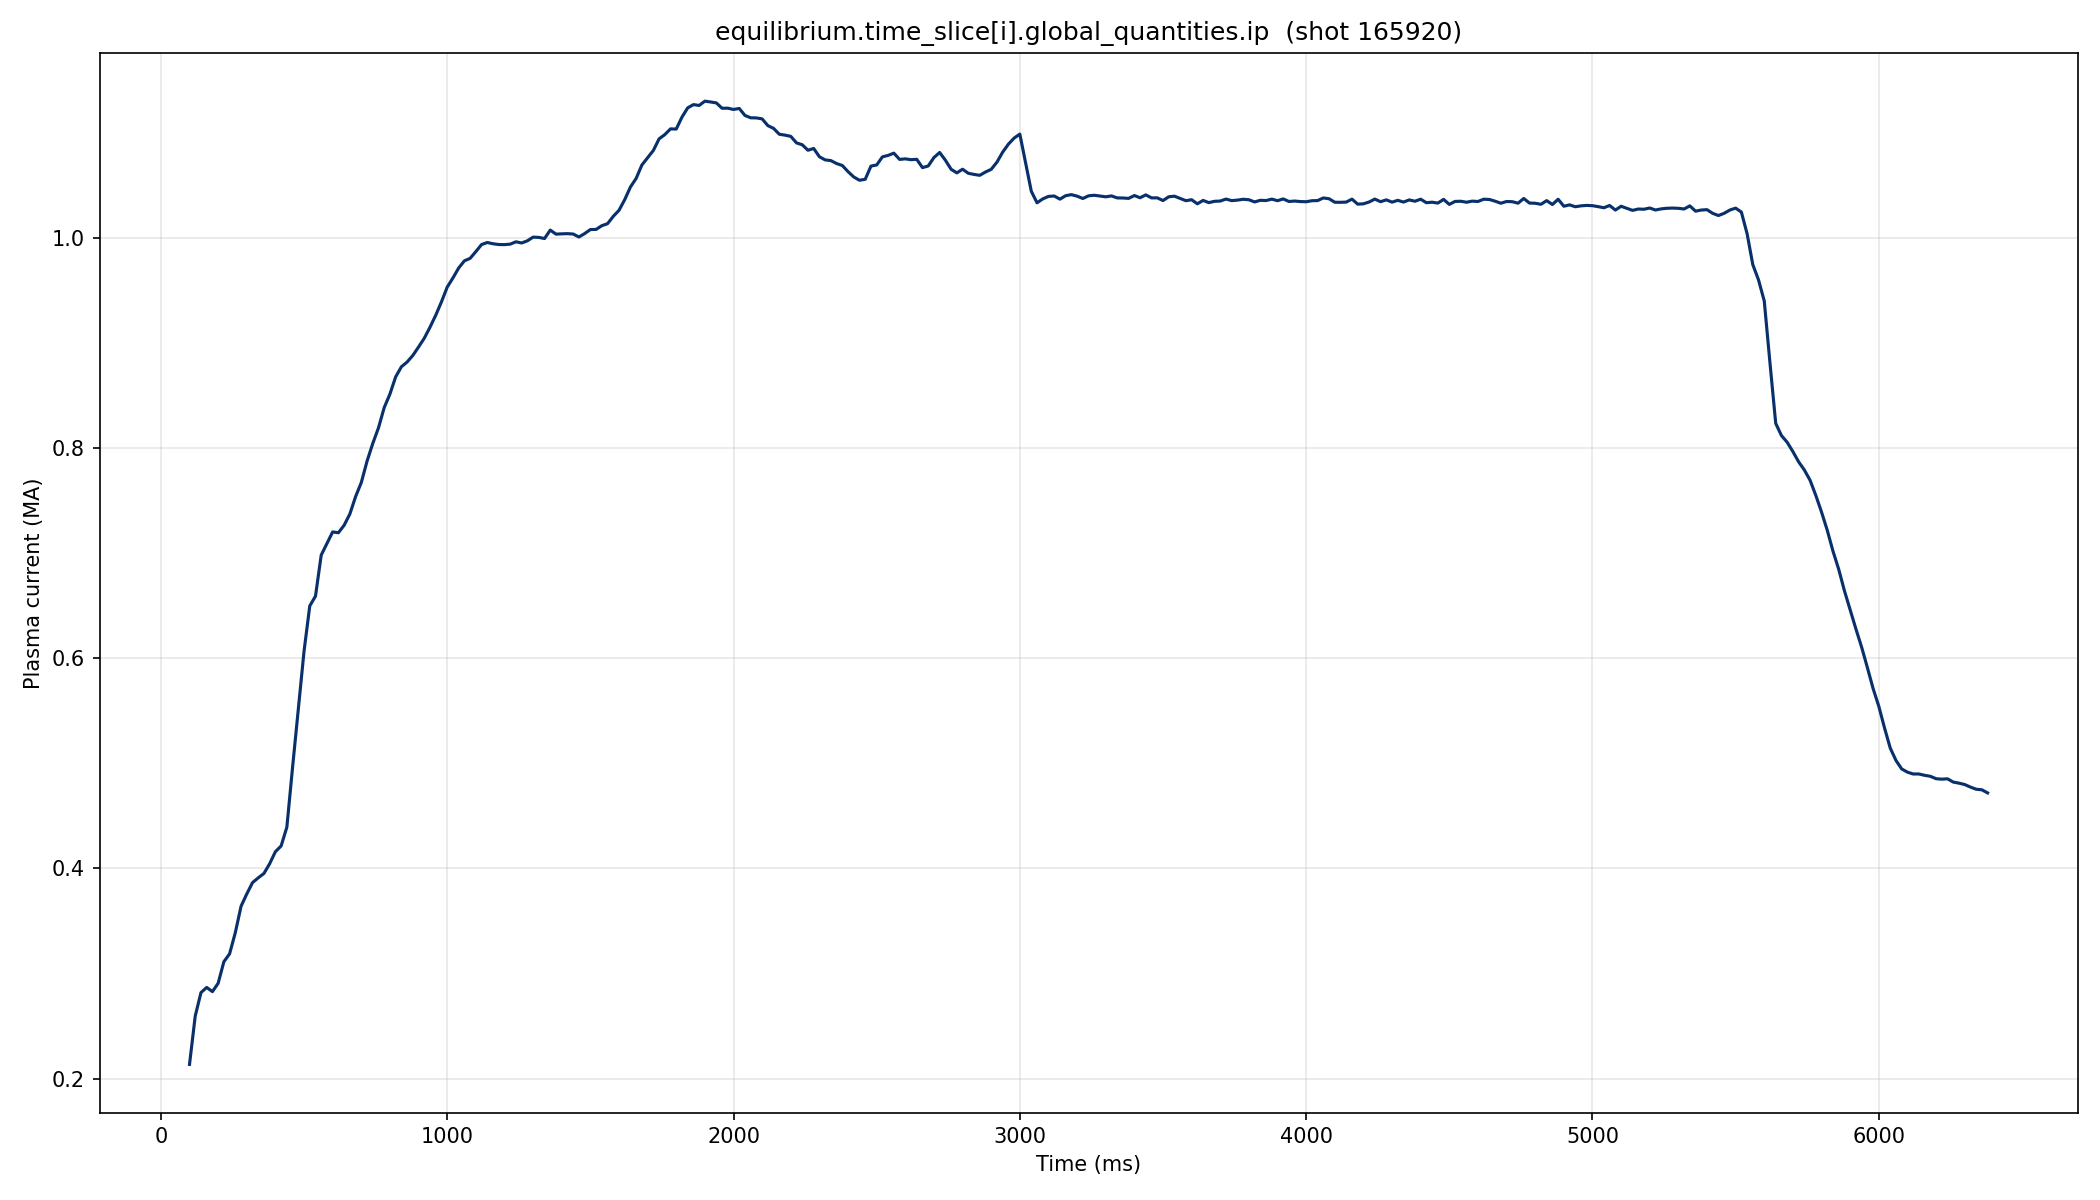

**Notes**

- **COCOS caution** : the mapping table flags this field with a TOR COCOS transform — the sign convention differs between DIII-D and IMAS, so a raw DIII-D value served under the IMAS name can be sign-flipped. The fetched trace is positive throughout (as expected for plasma current), so no sign flip is apparent here, but the caution applies to this field in general.
- **Source distinction** : this is the `MEASUREMENTS.CPASMA` node (the reconstructed current that the IMAS composer maps to `global_quantities.ip`), which is a *related but distinct* signal from `\ipmhd` (`RESULTS.AEQDSK:IPMHD`) — 315 samples vs 303, and slightly different min values, though the peaks agree exactly for this shot.
- Raw data saved as `imas_ip_165920.csv` (time_ms, ip_A) in the working directory.

In [19]:
%%ask
For DIII-D shot 165920, fetch equilibrium.time_slice[i].global_quantities.ip
and plot it versus time